In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [28]:

# STEP 1: LOAD DATASET AND EDA

# Load dataset (using a sample dataset or actual file)
# For demo, creating synthetic data (replace with actual CSV loading)
np.random.seed(42)
n_samples = 1000

data = {
    'Area': np.random.randint(800, 5000, n_samples),
    'Bedrooms': np.random.randint(1, 6, n_samples),
    'Bathrooms': np.random.randint(1, 4, n_samples),
    'Floors': np.random.randint(1, 3, n_samples),
    'Age': np.random.randint(0, 50, n_samples),
    'Location_Score': np.random.uniform(1, 10, n_samples),
    'Garage': np.random.randint(0, 3, n_samples),
    'Renovated': np.random.choice([0, 1], n_samples, p=[0.7, 0.3]),
    'Price': np.random.randint(100000, 800000, n_samples)
}

df = pd.DataFrame(data)

In [29]:
# Add some missing values
df.loc[10:20, 'Area'] = np.nan
df.loc[30:40, 'Bedrooms'] = np.nan
df.loc[50:60, 'Age'] = np.nan

In [4]:
# Check for null values
null_values = df.isnull().sum()

In [5]:
# Descriptive statistics
desc_stats = df.describe()

In [6]:
# Distribution of target variable
target_dist = df['Price'].describe()


In [7]:
# STEP 2: HANDLE MISSING VALUES & ENCODE CATEGORICAL

# Handle missing values - fill with median for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [8]:
# Add a categorical feature (for demonstration of One-Hot Encoding)
df['Location_Type'] = np.random.choice(['Urban', 'Suburban', 'Rural'], n_samples)


In [9]:
# Identify categorical and numerical columns
categorical_cols = ['Location_Type']
numerical_cols = [col for col in df.columns if col not in categorical_cols + ['Price']]

In [10]:
# One-Hot Encoding for categorical features
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [11]:
# STEP 3: FEATURE SELECTION & CORRELATION

# Correlation heatmap data
correlation_matrix = df_encoded.corr()
price_correlations = correlation_matrix['Price'].sort_values(ascending=False)


In [12]:
# Select features for modeling (excluding Price)
features = [col for col in df_encoded.columns if col != 'Price']
X = df_encoded[features]
y = df_encoded['Price']

In [13]:
# STEP 4: TRAIN/TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# STEP 5: BUILD PIPELINE WITH SCALING

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols)
    ],
    remainder='passthrough'
)


In [15]:
# Create full pipeline with Linear Regression
model_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])


In [16]:
#STEP 6: TRAIN LINEAR REGRESSION MODEL

model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)


In [17]:
# STEP 7: EVALUATE LINEAR REGRESSION

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

In [18]:
# STEP 8: RESIDUAL ANALYSIS

residuals_lr = y_test - y_pred_lr

In [19]:
# STEP 9: COEFFICIENT ANALYSIS

# Get feature names after preprocessing
feature_names = numerical_cols + [col for col in X_train.columns if col not in numerical_cols]
coefficients_lr = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model_lr.named_steps['regressor'].coef_
}).sort_values('Coefficient', ascending=False)


In [20]:
# STEP 10: RIDGE REGRESSION (Bonus)

model_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])
model_ridge.fit(X_train, y_train)
y_pred_ridge = model_ridge.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

In [21]:
# STEP 11: LASSO REGRESSION (Bonus)

model_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=0.1))
])
model_lasso.fit(X_train, y_train)
y_pred_lasso = model_lasso.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)


Text(0.5, 1.0, 'Linear Regression: Actual vs Predicted Prices')

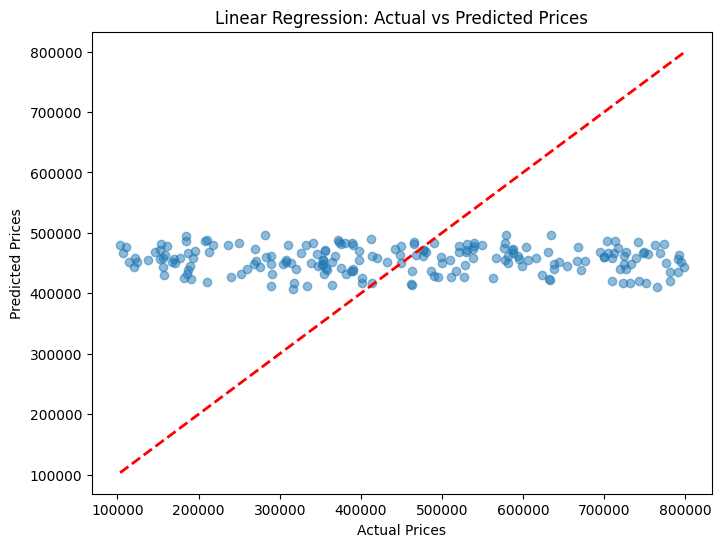

In [22]:
# STEP 12: VISUALIZATIONS

# Scatter plot: Actual vs Predicted
fig1, ax1 = plt.subplots(figsize=(8, 6))
ax1.scatter(y_test, y_pred_lr, alpha=0.5)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_xlabel('Actual Prices')
ax1.set_ylabel('Predicted Prices')
ax1.set_title('Linear Regression: Actual vs Predicted Prices')

Text(0.5, 1.0, 'Residual Plot')

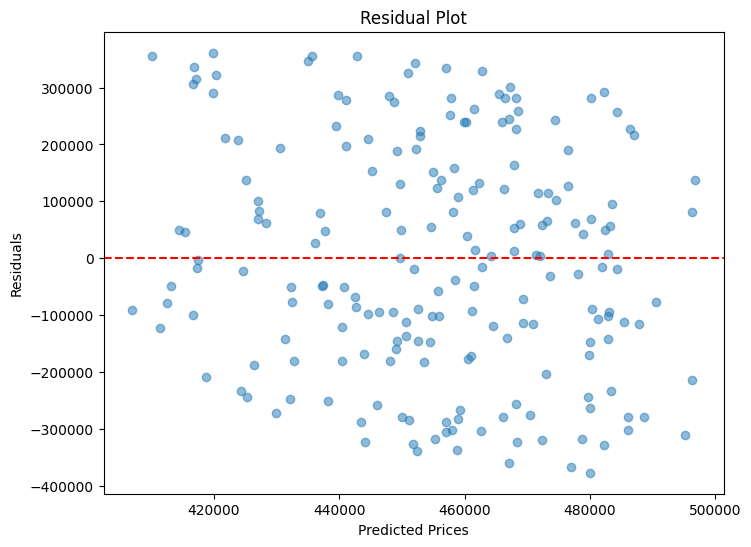

In [23]:
# Residual plot
fig2, ax2 = plt.subplots(figsize=(8, 6))
ax2.scatter(y_pred_lr, residuals_lr, alpha=0.5)
ax2.axhline(y=0, color='r', linestyle='--')
ax2.set_xlabel('Predicted Prices')
ax2.set_ylabel('Residuals')
ax2.set_title('Residual Plot')

Text(0.5, 1.0, 'Feature Correlation Heatmap')

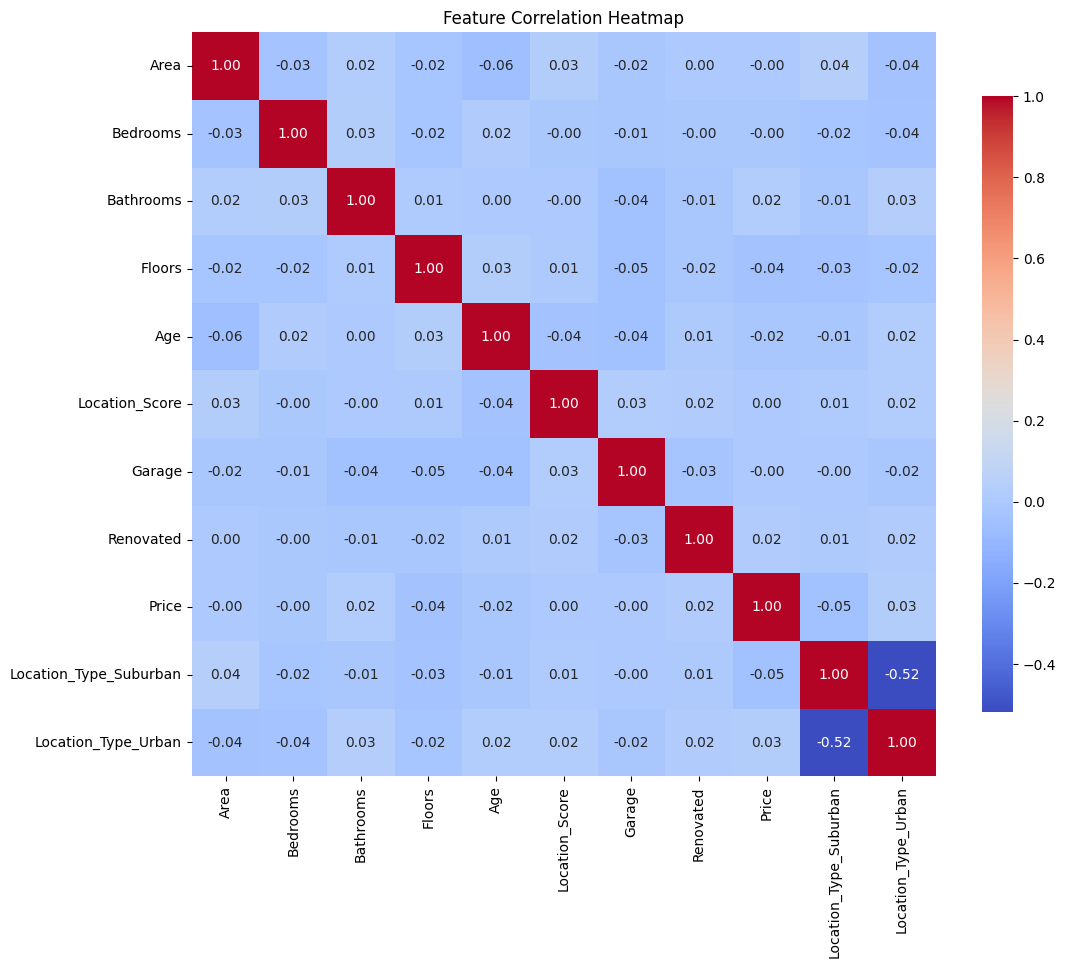

In [24]:
# Correlation heatmap
fig3, ax3 = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, ax=ax3, cbar_kws={"shrink": 0.8})
ax3.set_title('Feature Correlation Heatmap')

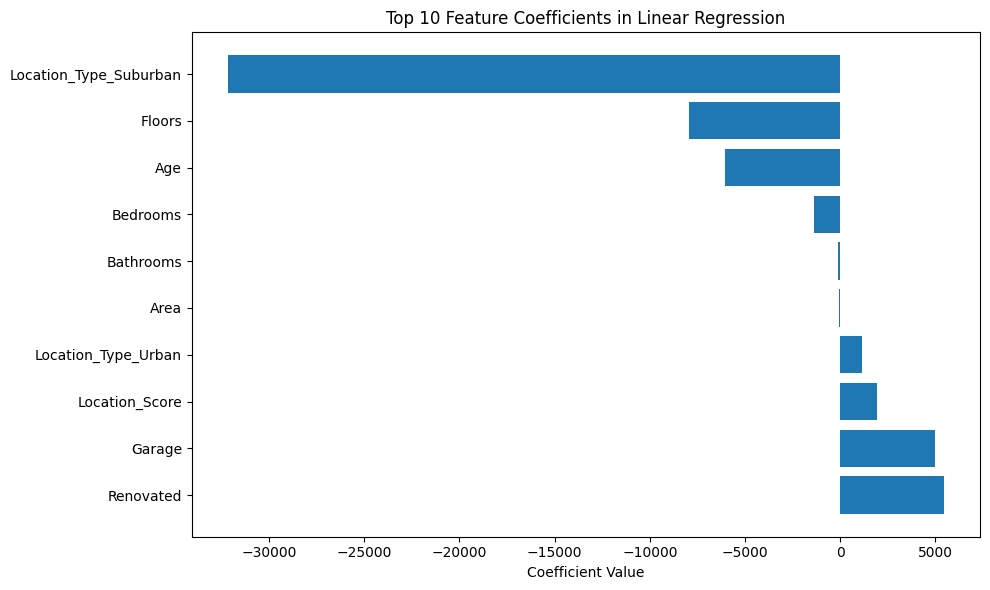

In [25]:
# Feature importance (coefficients)
fig4, ax4 = plt.subplots(figsize=(10, 6))
top_features = coefficients_lr.head(10)
ax4.barh(top_features['Feature'], top_features['Coefficient'])
ax4.set_xlabel('Coefficient Value')
ax4.set_title('Top 10 Feature Coefficients in Linear Regression')

plt.tight_layout()
plt.show()

In [26]:
# STEP 13: MODEL COMPARISON SUMMARY

model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'MSE': [mse_lr, mse_ridge, mse_lasso],
    'RMSE': [rmse_lr, rmse_ridge, rmse_lasso],
    'R² Score': [r2_lr, r2_ridge, r2_lasso]
})